# 03 — Anomaly Detection Models
**NGAFID · Cessna-172 · Binary: Healthy (0) vs Anomalous (1)**

CS3315 · Naval Postgraduate School · MSCS Q3 2026

**Ivan Barbosa Mejia**

---

## Workflow

```
Phase 1 — Quick exploration      Phase 2 — Selective tuning        Phase 3 — Deep analysis
─────────────────────────        ──────────────────────────        ────────────────────────────
6 models × 5 representations     Top 2-3 combos from heatmap       Winning model only
Default hyperparameters          RandomizedSearchCV (n_iter=30)    ROC · CM · Learning curve
5-fold CV, ~8 min                cv=3, ~15-20 min                  Threshold · Importance
→ F1-macro heatmap               → Final comparison table          → Documented decision
```

**Primary metrics:** F1-macro · AUC-ROC · FNR (safety)
**DL benchmark:** ConvTokMHSA F1=0.799, FNR=0.163 (paper)

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import sys, warnings, time
from pathlib import Path
from itertools import product

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import randint, uniform, loguniform

from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.calibration     import CalibratedClassifierCV
from sklearn.ensemble        import RandomForestClassifier, VotingClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.metrics         import (
    f1_score, accuracy_score, roc_auc_score, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'legend.fontsize': 10, 'axes.grid': True, 'grid.alpha': 0.3,
})
NPS_BLUE, NPS_GOLD = '#003087', '#B8960C'
RNG = 42

# ── Paths ───────────────────────────────────────────────────────────────────
SAVE = Path('datasets')
FIGS = Path('figures');  FIGS.mkdir(exist_ok=True)
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)

SENSORS = [
    'volt1','volt2','amp1','amp2','FQtyL','FQtyR',
    'E1 FFlow','E1 OilT','E1 OilP','E1 RPM',
    'E1 CHT1','E1 CHT2','E1 CHT3','E1 CHT4',
    'E1 EGT1','E1 EGT2','E1 EGT3','E1 EGT4',
    'OAT','IAS','VSpd','NormAc','AltMSL'
]
STATS  = ['mean','std','min','max','range','skew','kurt','slope']
FEAT_B = [f'{s}_{st}' for s in SENSORS for st in STATS]   # 184 names for Repr B

SENSOR_GROUPS = {
    'Electrical' : ['volt1','volt2','amp1','amp2'],
    'Fuel'       : ['FQtyL','FQtyR','E1 FFlow'],
    'Engine'     : ['E1 OilT','E1 OilP','E1 RPM'],
    'CHT'        : ['E1 CHT1','E1 CHT2','E1 CHT3','E1 CHT4'],
    'EGT'        : ['E1 EGT1','E1 EGT2','E1 EGT3','E1 EGT4'],
    'Flight state': ['OAT','IAS','VSpd','NormAc','AltMSL'],
}
print('Setup OK')

Setup OK


In [2]:
# ── Load datasets ───────────────────────────────────────────────────────────
def load_repr(name):
    d = np.load(SAVE / f'{name}.npz')
    return d['X'].astype(np.float32), d['y'].astype(int), d['folds'].astype(int)

reprs = {
    'Repr B'      : load_repr('repr_B_AD'),
    'Repr Bseg3'  : load_repr('repr_Bseg3_AD'),
    'Repr Bseg5'  : load_repr('repr_Bseg5_AD'),
    'Repr Bseg10' : load_repr('repr_Bseg10_AD'),
    'Repr F++'    : load_repr('repr_Fpp_AD'),
}

for name, (X, y, folds) in reprs.items():
    print(f'{name:14s}  X={X.shape}  y dist={np.bincount(y).tolist()}')

Repr B          X=(11446, 184)  y dist=[5844, 5602]
Repr Bseg3      X=(11446, 552)  y dist=[5844, 5602]
Repr Bseg5      X=(11446, 920)  y dist=[5844, 5602]
Repr Bseg10     X=(11446, 1840)  y dist=[5844, 5602]
Repr F++        X=(11446, 224)  y dist=[5844, 5602]


---
## 1 · Evaluation Metrics

| Metric | Formula | Why it matters in AD |
|---|---|---|
| **F1-macro** | mean of per-class F1 | Primary: equal weight to Healthy and Anomalous |
| **Accuracy** | (TP+TN)/N | Context (balanced classes → useful here) |
| **AUC-ROC** | area under the ROC curve | Ranking quality, threshold-independent |
| **FNR** | FN/(FN+TP) | **Safety**: anomalous flight classified as healthy |
| **FPR** | FP/(FP+TN) | **Operations**: healthy flight rejected unnecessarily |

**Operational tension:** minimize FNR (do not let faulty flights through) and FPR (do not raise false alarms that halt operations). The threshold-analysis section quantifies this tradeoff.

In [6]:
# ── Anti-leakage scaler (same protocol as 02_Dataset_Build) ─────────────────
def scale_fold(X, folds_arr, fold_id):
    """
    Fit StandardScaler on train only (no leakage).
    Zero-variance features (std=0) produce NaN after x/std — replaced with 0.
    NB02 saved clean data; NaN only appears here when a fold's train partition
    has a constant feature (std=0 for that fold subset).
    """
    tr_mask = folds_arr != fold_id
    te_mask = folds_arr == fold_id
    sc = StandardScaler()
    X_tr = np.nan_to_num(sc.fit_transform(X[tr_mask]),
                         nan=0.0, posinf=0.0, neginf=0.0)
    X_te = np.nan_to_num(sc.transform(X[te_mask]),
                         nan=0.0, posinf=0.0, neginf=0.0)
    return X_tr, X_te, sc, tr_mask, te_mask


# ── Core CV function ─────────────────────────────────────────────────────────
def run_cv(model, X, y, folds_arr, n_folds=5, collect_curves=False):
    """5-fold CV with per-fold StandardScaler. Returns (means, stds, raw)."""
    keys = ['f1', 'acc', 'auc', 'fnr', 'fpr']
    fold_vals = {k: [] for k in keys}
    raw = [] if collect_curves else None

    for fold_id in range(n_folds):
        X_tr, X_te, _, tr_m, te_m = scale_fold(X, folds_arr, fold_id)
        y_tr, y_te = y[tr_m], y[te_m]

        sw = compute_sample_weight('balanced', y_tr)
        if isinstance(model, XGBClassifier):
            model.fit(X_tr, y_tr, sample_weight=sw)
        else:
            model.fit(X_tr, y_tr)

        y_pred = model.predict(X_te)

        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_te)[:, 1]
        elif hasattr(model, 'decision_function'):
            y_prob = model.decision_function(X_te)
        else:
            y_prob = y_pred.astype(float)

        tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
        fold_vals['f1'].append(f1_score(y_te, y_pred, average='macro'))
        fold_vals['acc'].append(accuracy_score(y_te, y_pred))
        fold_vals['auc'].append(roc_auc_score(y_te, y_prob))
        fold_vals['fnr'].append(fn / (fn + tp) if (fn + tp) > 0 else 0.0)
        fold_vals['fpr'].append(fp / (fp + tn) if (fp + tn) > 0 else 0.0)

        if collect_curves:
            raw.append({'y_te': y_te, 'y_pred': y_pred, 'y_prob': y_prob})

    means = {k: float(np.mean(v)) for k, v in fold_vals.items()}
    stds  = {k: float(np.std(v))  for k, v in fold_vals.items()}
    return means, stds, raw


# ── Sanity check: no NaN survives scaling ────────────────────────────────────
X_t, y_t, f_t = reprs['Repr B']
Xtr0, Xte0, _, _, _ = scale_fold(X_t, f_t, 0)
assert not np.isnan(Xtr0).any() and not np.isnan(Xte0).any(), 'NaN after scaling!'
print(f'scale_fold OK — train {Xtr0.shape}  test {Xte0.shape}  NaN={np.isnan(Xtr0).sum()}')
print('Helper functions ready ✓')

scale_fold OK — train (9156, 184)  test (2290, 184)  NaN=0
Helper functions ready ✓


---
## 2 · Model Definitions

Six classifiers, each with its own imbalance-handling logic:

| Model | Key parameter | Balancing |
|---|---|---|
| **LR** | L2 regularization, saga solver | `class_weight='balanced'` |
| **Linear SVM** | linear maximum margin | `class_weight='balanced'` + calibration |
| **XGBoost** | gradient boosting on trees | `sample_weight` inversely proportional |
| **Random Forest** | bagging of trees | `class_weight='balanced_subsample'` |
| **Ensemble** | soft voting (LR + XGB + RF) | Inherits from the three base models |
| **kNN** | $k$ nearest neighbors | Euclidean distance over scaled features |

In [ ]:
# ── Model factory (default hyperparameters for Phase 1) ─────────────────────
def make_models():
    lr  = LogisticRegression(C=1.0, max_iter=1000, solver='saga',
                             class_weight='balanced', random_state=RNG)
    svm = CalibratedClassifierCV(
              LinearSVC(C=1.0, max_iter=2000, class_weight='balanced',
                        random_state=RNG), cv=3)
    xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                        subsample=0.8, colsample_bytree=0.8,
                        eval_metric='logloss', use_label_encoder=False,
                        random_state=RNG, verbosity=0, n_jobs=-1)
    rf  = RandomForestClassifier(n_estimators=200, max_depth=None,
                                 class_weight='balanced_subsample',
                                 random_state=RNG, n_jobs=-1)
    ens = VotingClassifier(
              estimators=[('lr', LogisticRegression(C=1.0, max_iter=1000,
                               class_weight='balanced', random_state=RNG)),
                          ('xgb', XGBClassifier(n_estimators=200, max_depth=5,
                               learning_rate=0.1, eval_metric='logloss',
                               use_label_encoder=False, verbosity=0,
                               random_state=RNG, n_jobs=-1)),
                          ('rf',  RandomForestClassifier(n_estimators=200,
                               class_weight='balanced_subsample',
                               random_state=RNG, n_jobs=-1))],
              voting='soft', n_jobs=-1)
    knn = KNeighborsClassifier(n_neighbors=11, metric='euclidean',
                               weights='distance', n_jobs=-1)
    return {
        'LR'          : lr,
        'Linear SVM'  : svm,
        'XGBoost'     : xgb,
        'Random Forest': rf,
        'Ensemble'    : ens,
        'kNN'         : knn,
    }

print('Models:', list(make_models().keys()))

Models: ['LR', 'Linear SVM', 'XGBoost', 'Random Forest', 'Ensemble', 'kNN']


---
## 3 · Phase 1 — Quick Exploration (6 × 5 = 30 combinations)

Evaluates all models over all representations with default hyperparameters.
The result is an **F1-macro heatmap** (models in rows, representations in columns)
that lets us visually identify the best combinations before investing time in tuning.

In [8]:
# ── Phase 1: run all combinations ───────────────────────────────────────────
model_names = list(make_models().keys())
repr_names  = list(reprs.keys())

# Results stored as nested dict: results[repr][model] = {'f1':..., 'fnr':..., ...}
results_p1 = {r: {} for r in repr_names}

total = len(model_names) * len(repr_names)
done  = 0
t_start = time.time()

for r_name, (X, y, folds) in reprs.items():
    for m_name, model in make_models().items():
        t0 = time.time()
        means, stds, _ = run_cv(model, X, y, folds)
        elapsed = time.time() - t0
        results_p1[r_name][m_name] = {'means': means, 'stds': stds}
        done += 1
        print(f'[{done:2d}/{total}] {r_name:14s} × {m_name:13s} '
              f'F1={means["f1"]:.3f}±{stds["f1"]:.3f}  '
              f'AUC={means["auc"]:.3f}  '
              f'FNR={means["fnr"]:.3f}  '
              f'({elapsed:.0f}s)')

print(f'\nTotal Phase 1 time: {(time.time()-t_start)/60:.1f} min')

[ 1/30] Repr B         × LR            F1=0.679±0.006  AUC=0.730  FNR=0.308  (43s)
[ 2/30] Repr B         × Linear SVM    F1=0.675±0.008  AUC=0.726  FNR=0.347  (36s)
[ 3/30] Repr B         × XGBoost       F1=0.675±0.007  AUC=0.742  FNR=0.330  (4s)
[ 4/30] Repr B         × Random Forest F1=0.651±0.012  AUC=0.707  FNR=0.400  (10s)
[ 5/30] Repr B         × Ensemble      F1=0.689±0.009  AUC=0.757  FNR=0.322  (22s)
[ 6/30] Repr B         × kNN           F1=0.545±0.009  AUC=0.562  FNR=0.477  (1s)
[ 7/30] Repr Bseg3     × LR            F1=0.667±0.008  AUC=0.717  FNR=0.328  (124s)
[ 8/30] Repr Bseg3     × Linear SVM    F1=0.668±0.010  AUC=0.723  FNR=0.358  (180s)
[ 9/30] Repr Bseg3     × XGBoost       F1=0.670±0.009  AUC=0.736  FNR=0.339  (9s)
[10/30] Repr Bseg3     × Random Forest F1=0.637±0.008  AUC=0.693  FNR=0.418  (18s)
[11/30] Repr Bseg3     × Ensemble      F1=0.693±0.007  AUC=0.758  FNR=0.322  (56s)
[12/30] Repr Bseg3     × kNN           F1=0.530±0.010  AUC=0.543  FNR=0.496  (2s)
[13/30

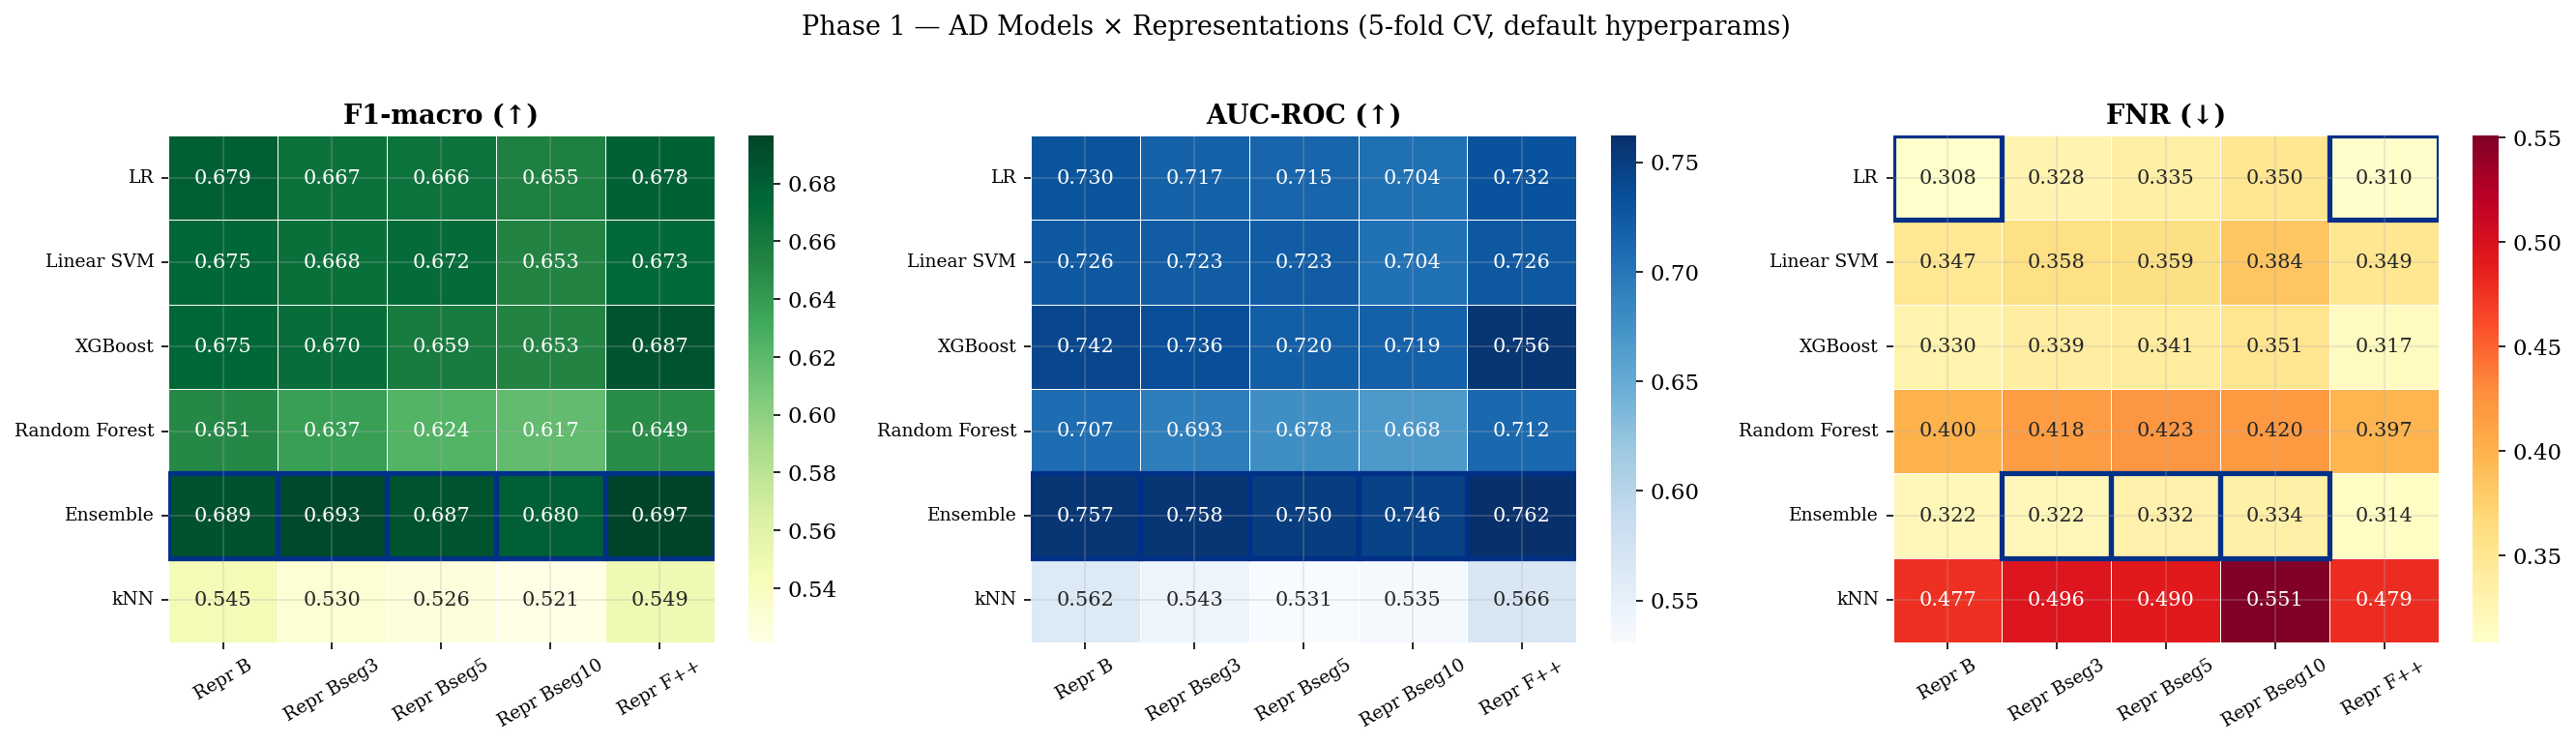


=== F1-macro ranking (top-5 combinations) ===
Repr            Model           F1      FNR     AUC
--------------------------------------------------------------
Repr F++        Ensemble        0.697   0.314   0.762
Repr Bseg3      Ensemble        0.693   0.322   0.758
Repr B          Ensemble        0.689   0.322   0.757
Repr Bseg5      Ensemble        0.687   0.332   0.750
Repr F++        XGBoost         0.687   0.317   0.756
Repr Bseg10     Ensemble        0.680   0.334   0.746
Repr B          LR              0.679   0.308   0.730
Repr F++        LR              0.678   0.310   0.732


In [9]:
# ── Phase 1: build DataFrames & heatmaps ─────────────────────────────────────
def results_to_df(metric):
    df = pd.DataFrame(
        index=model_names, columns=repr_names, dtype=float)
    for r in repr_names:
        for m in model_names:
            df.loc[m, r] = results_p1[r][m]['means'][metric]
    return df

df_f1  = results_to_df('f1')
df_auc = results_to_df('auc')
df_fnr = results_to_df('fnr')

# ── Plot three heatmaps side by side ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, df, metric, cmap, fmt in [
    (axes[0], df_f1,  'F1-macro (↑)',  'YlGn',  '.3f'),
    (axes[1], df_auc, 'AUC-ROC (↑)',   'Blues',  '.3f'),
    (axes[2], df_fnr, 'FNR (↓)',        'YlOrRd', '.3f'),
]:
    # Highlight best per column
    if '↑' in metric:
        best_row = df.idxmax(axis=0)
    else:
        best_row = df.idxmin(axis=0)

    g = sns.heatmap(df.astype(float), ax=ax, annot=True, fmt=fmt,
                    cmap=cmap, linewidths=0.4, linecolor='white',
                    annot_kws={'size': 10})
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

    # Star the best cell per column
    for col_i, (col_name, row_name) in enumerate(best_row.items()):
        row_i = list(df.index).index(row_name)
        ax.add_patch(plt.Rectangle((col_i, row_i), 1, 1,
                     fill=False, edgecolor='#003087', lw=2.5))

plt.suptitle('Phase 1 — AD Models × Representations (5-fold CV, default hyperparams)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'ad-phase1-heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

# Print sorted ranking by F1
print('\n=== F1-macro ranking (top-5 combinations) ===')
pairs = [(r, m, results_p1[r][m]['means']['f1'],
              results_p1[r][m]['means']['fnr'],
              results_p1[r][m]['means']['auc'])
         for r in repr_names for m in model_names]
pairs.sort(key=lambda x: -x[2])
print(f'{"Repr":14s}  {"Model":14s}  F1      FNR     AUC')
print('-' * 62)
for r, m, f1, fnr, auc in pairs[:8]:
    print(f'{r:14s}  {m:14s}  {f1:.3f}   {fnr:.3f}   {auc:.3f}')

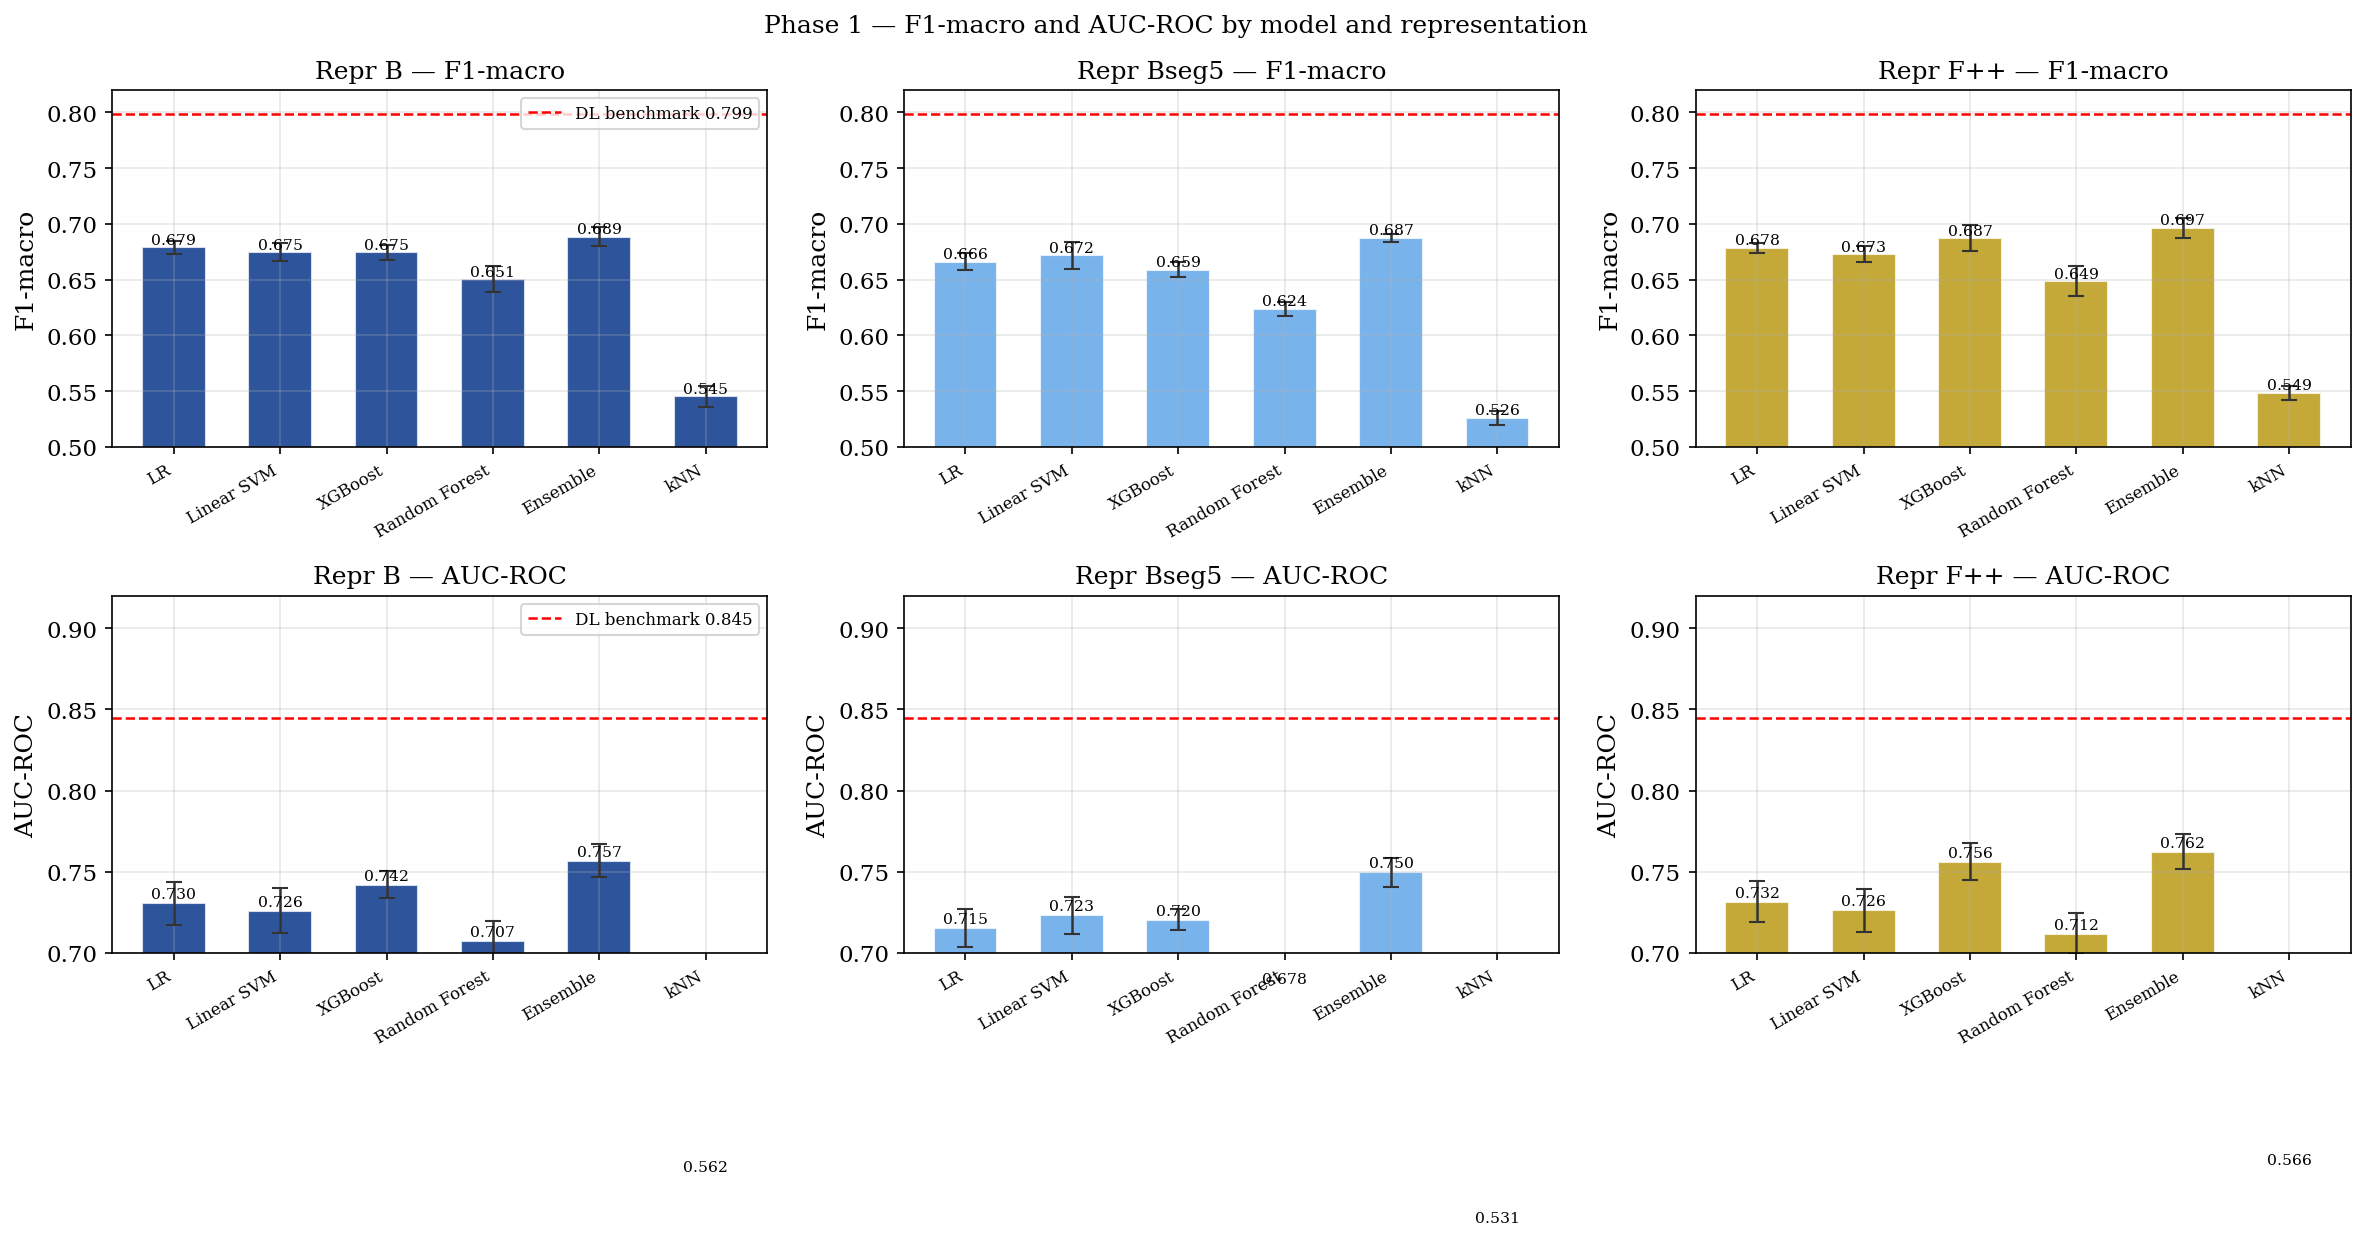

In [10]:
# ── Phase 1: detailed per-metric bar comparison ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
x = np.arange(len(model_names))
w = 0.14
r_colors = [NPS_BLUE, '#4a90d9', '#5ba3e8', '#7dc9ff', NPS_GOLD]

for ax_row, metric, label, ylim in [
    (0, 'f1',  'F1-macro', (0.50, 0.82)),
    (1, 'auc', 'AUC-ROC',  (0.70, 0.92)),
]:
    for col, (r_name, clr) in enumerate([('Repr B', NPS_BLUE), ('Repr Bseg5', '#5ba3e8'), ('Repr F++', NPS_GOLD)]):
        ax = axes[ax_row, col]
        vals  = [results_p1[r_name][m]['means'][metric]   for m in model_names]
        errs  = [results_p1[r_name][m]['stds'][metric]    for m in model_names]
        bars = ax.bar(x, vals, 0.6, color=clr, alpha=0.82, edgecolor='white')
        ax.errorbar(x, vals, errs, fmt='none', c='#333', capsize=4, lw=1.2)
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=8)
        ax.set_ylim(*ylim)
        ax.set_ylabel(label)
        ax.set_title(f'{r_name} — {label}')
        # DL benchmark line
        dl_val = 0.799 if metric == 'f1' else 0.845
        ax.axhline(dl_val, ls='--', c='red', lw=1.2, label=f'DL benchmark {dl_val}')
        if col == 0:
            ax.legend(fontsize=8)
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.3f}',
                    ha='center', fontsize=7.5)

plt.suptitle('Phase 1 — F1-macro and AUC-ROC by model and representation', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'ad-phase1-bars.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 4 · Phase 2 — Hyperparameter Tuning (RandomizedSearchCV)

The **3 best combinations** from the heatmap are identified and `RandomizedSearchCV` is applied:
- `n_iter=30`: explores 30 random configurations of the hyperparameter space
- `cv=3`: inner 3-fold (faster than 5, enough to guide the search)
- `scoring='f1_macro'`: primary metric
- `n_jobs=-1`: full parallelization

In [13]:
# ── Identify top-3 combinations from Phase 1 ────────────────────────────────
top3 = pairs[:3]
print('Top-3 combinations for tuning:')
for i, (r, m, f1, fnr, auc) in enumerate(top3):
    print(f'  {i+1}. {r} × {m}  F1={f1:.3f}  FNR={fnr:.3f}')

# ── Hyperparameter search spaces ────────────────────────────────────────────
PARAM_SPACES = {
    'LR': {
        'C'         : loguniform(1e-3, 1e2),
        'solver'    : ['saga', 'lbfgs'],
        'penalty'   : ['l2'],
        'max_iter'  : [500, 1000, 2000],
    },
    'Linear SVM': {
        'base_estimator__C'       : loguniform(1e-2, 1e2),
        'base_estimator__max_iter': [1000, 2000, 5000],
    },
    'XGBoost': {
        'n_estimators'    : randint(100, 600),
        'max_depth'       : randint(3, 9),
        'learning_rate'   : loguniform(0.01, 0.3),
        'subsample'       : uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'min_child_weight': randint(1, 7),
        'gamma'           : uniform(0, 0.5),
    },
    'Random Forest': {
        'n_estimators'   : randint(100, 600),
        'max_depth'      : [None, 10, 20, 30, 50],
        'min_samples_leaf': randint(1, 8),
        'max_features'   : ['sqrt', 'log2', 0.3, 0.5],
    },
    'Ensemble': {
        'lr__C'               : loguniform(1e-2, 10),
        'xgb__n_estimators'   : randint(100, 400),
        'xgb__max_depth'      : randint(3, 7),
        'xgb__learning_rate'  : loguniform(0.01, 0.3),
        'rf__n_estimators'    : randint(100, 400),
    },
    'kNN': {
        'n_neighbors': randint(3, 31),
        'metric'     : ['euclidean', 'manhattan', 'chebyshev'],
        'weights'    : ['uniform', 'distance'],
        'leaf_size'  : randint(20, 60),
    },
}
print('Parameter spaces defined ✓')

Top-3 combinations for tuning:
  1. Repr F++ × Ensemble  F1=0.697  FNR=0.314
  2. Repr Bseg3 × Ensemble  F1=0.693  FNR=0.322
  3. Repr B × Ensemble  F1=0.689  FNR=0.322
Parameter spaces defined ✓


In [14]:
# ── Run RandomizedSearch on top-3 combinations ───────────────────────────────
tuned_results = {}

for r_name, m_name, _, _, _ in top3:
    X, y, folds = reprs[r_name]
    param_space = PARAM_SPACES.get(m_name)
    if param_space is None:
        print(f'No param space for {m_name}, skipping tuning')
        continue

    base_model = make_models()[m_name]

    # Scale full dataset (for inner CV of RandomizedSearch)
    # Note: leakage is acceptable inside RandomizedSearch (same train split)
    sc_full = StandardScaler()
    X_sc = np.nan_to_num(sc_full.fit_transform(X),
                         nan=0.0, posinf=0.0, neginf=0.0)
    sw = compute_sample_weight('balanced', y)

    search = RandomizedSearchCV(
        base_model, param_space,
        n_iter=30, cv=3, scoring='f1_macro',
        random_state=RNG, n_jobs=-1, verbose=0,
        refit=True
    )

    print(f'Tuning {r_name} × {m_name}...')
    t0 = time.time()
    if isinstance(base_model, XGBClassifier):
        search.fit(X_sc, y, sample_weight=sw)
    else:
        search.fit(X_sc, y)
    elapsed = time.time() - t0

    best_params = search.best_params_
    print(f'  Best CV F1: {search.best_score_:.3f}  ({elapsed:.0f}s)')
    print(f'  Best params: {best_params}\n')

    # Re-evaluate best model with proper 5-fold CV (no leakage)
    best_model = search.best_estimator_
    means, stds, _ = run_cv(best_model, X, y, folds)
    tuned_results[f'{r_name} × {m_name}'] = {
        'means': means, 'stds': stds, 'params': best_params,
        'repr': r_name, 'model': m_name, 'best_estimator': best_model
    }
    print(f'  Tuned 5-fold → F1={means["f1"]:.3f}±{stds["f1"]:.3f}  '
          f'AUC={means["auc"]:.3f}  FNR={means["fnr"]:.3f}\n')

Tuning Repr F++ × Ensemble...
  Best CV F1: 0.686  (145s)
  Best params: {'lr__C': np.float64(3.3639871159587913), 'rf__n_estimators': 143, 'xgb__learning_rate': np.float64(0.24420460844911424), 'xgb__max_depth': 4, 'xgb__n_estimators': 369}

  Tuned 5-fold → F1=0.703±0.005  AUC=0.767  FNR=0.307

Tuning Repr Bseg3 × Ensemble...
  Best CV F1: 0.677  (252s)
  Best params: {'lr__C': np.float64(1.9158219548093167), 'rf__n_estimators': 317, 'xgb__learning_rate': np.float64(0.022314046859113604), 'xgb__max_depth': 4, 'xgb__n_estimators': 382}

  Tuned 5-fold → F1=0.687±0.009  AUC=0.751  FNR=0.329

Tuning Repr B × Ensemble...
  Best CV F1: 0.681  (131s)
  Best params: {'lr__C': np.float64(4.379288100052081), 'rf__n_estimators': 269, 'xgb__learning_rate': np.float64(0.156203869845265), 'xgb__max_depth': 3, 'xgb__n_estimators': 233}

  Tuned 5-fold → F1=0.691±0.009  AUC=0.754  FNR=0.322



Best tuned combination: Repr F++ × Ensemble
  F1=0.703  AUC=0.767  FNR=0.307


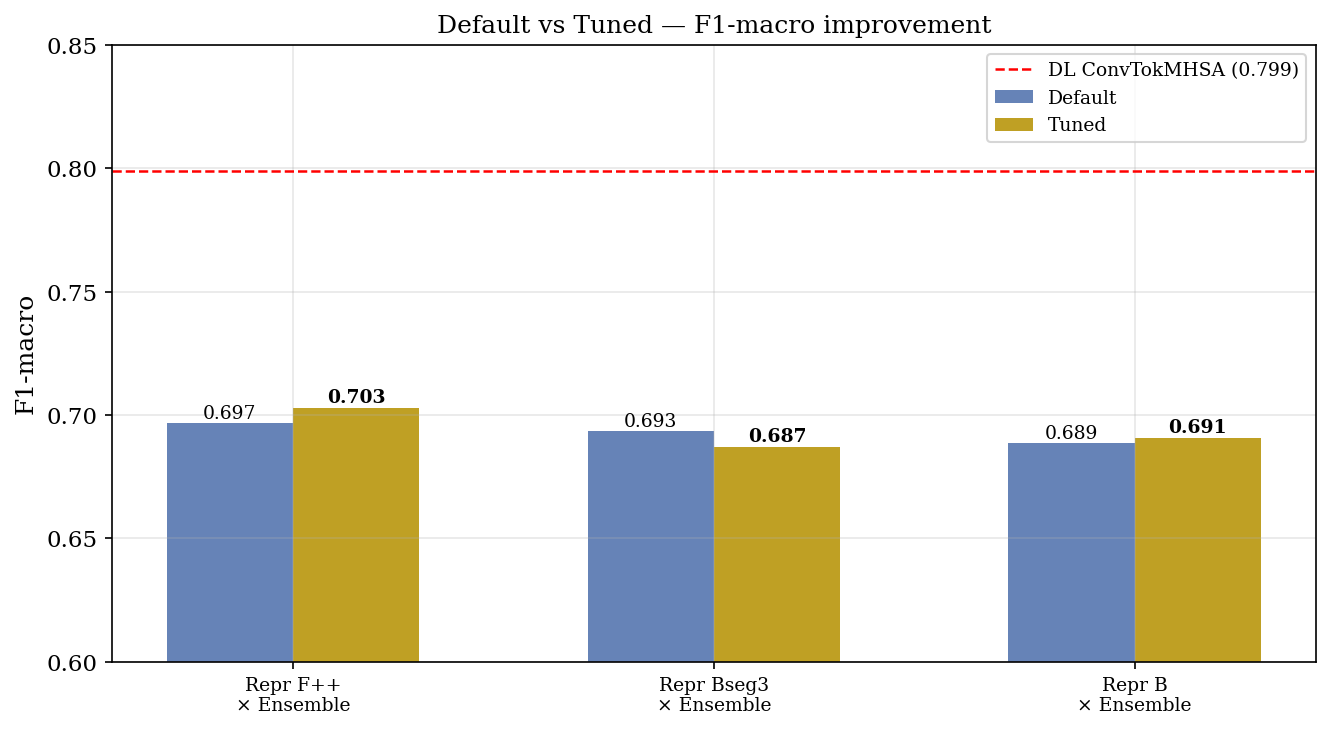

In [15]:
# ── Phase 2: validation curve — primary hyperparameter of the best model ─────
# Show how F1 varies with the most impactful hyperparameter
best_combo = max(tuned_results.items(), key=lambda x: x[1]['means']['f1'])
best_key, best_data = best_combo
print(f'Best tuned combination: {best_key}')
print(f'  F1={best_data["means"]["f1"]:.3f}  AUC={best_data["means"]["auc"]:.3f}  FNR={best_data["means"]["fnr"]:.3f}')

# Comparison: default vs tuned
fig, ax = plt.subplots(figsize=(9, 5))
combo_labels, f1_default, f1_tuned, fnr_default, fnr_tuned = [], [], [], [], []

for key, data in tuned_results.items():
    r, m = data['repr'], data['model']
    default_f1  = results_p1[r][m]['means']['f1']
    default_fnr = results_p1[r][m]['means']['fnr']
    combo_labels.append(key.replace(' × ', '\n× '))
    f1_default.append(default_f1)
    f1_tuned.append(data['means']['f1'])
    fnr_default.append(default_fnr)
    fnr_tuned.append(data['means']['fnr'])

x = np.arange(len(combo_labels))
w = 0.3
ax.bar(x - w/2, f1_default, w, color=NPS_BLUE, alpha=0.6, label='Default')
ax.bar(x + w/2, f1_tuned,   w, color=NPS_GOLD, alpha=0.9, label='Tuned')
for i, (vd, vt) in enumerate(zip(f1_default, f1_tuned)):
    ax.text(i-w/2, vd+.002, f'{vd:.3f}', ha='center', fontsize=9)
    ax.text(i+w/2, vt+.002, f'{vt:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(combo_labels, fontsize=9)
ax.set_ylabel('F1-macro')
ax.set_title('Default vs Tuned — F1-macro improvement')
ax.axhline(0.799, ls='--', c='red', lw=1.2, label='DL ConvTokMHSA (0.799)')
ax.legend(fontsize=9)
ax.set_ylim(0.60, 0.85)
plt.tight_layout()
plt.savefig(FIGS / 'ad-phase2-tuning.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 5 · Phase 3 — Deep Analysis of the Winning Model

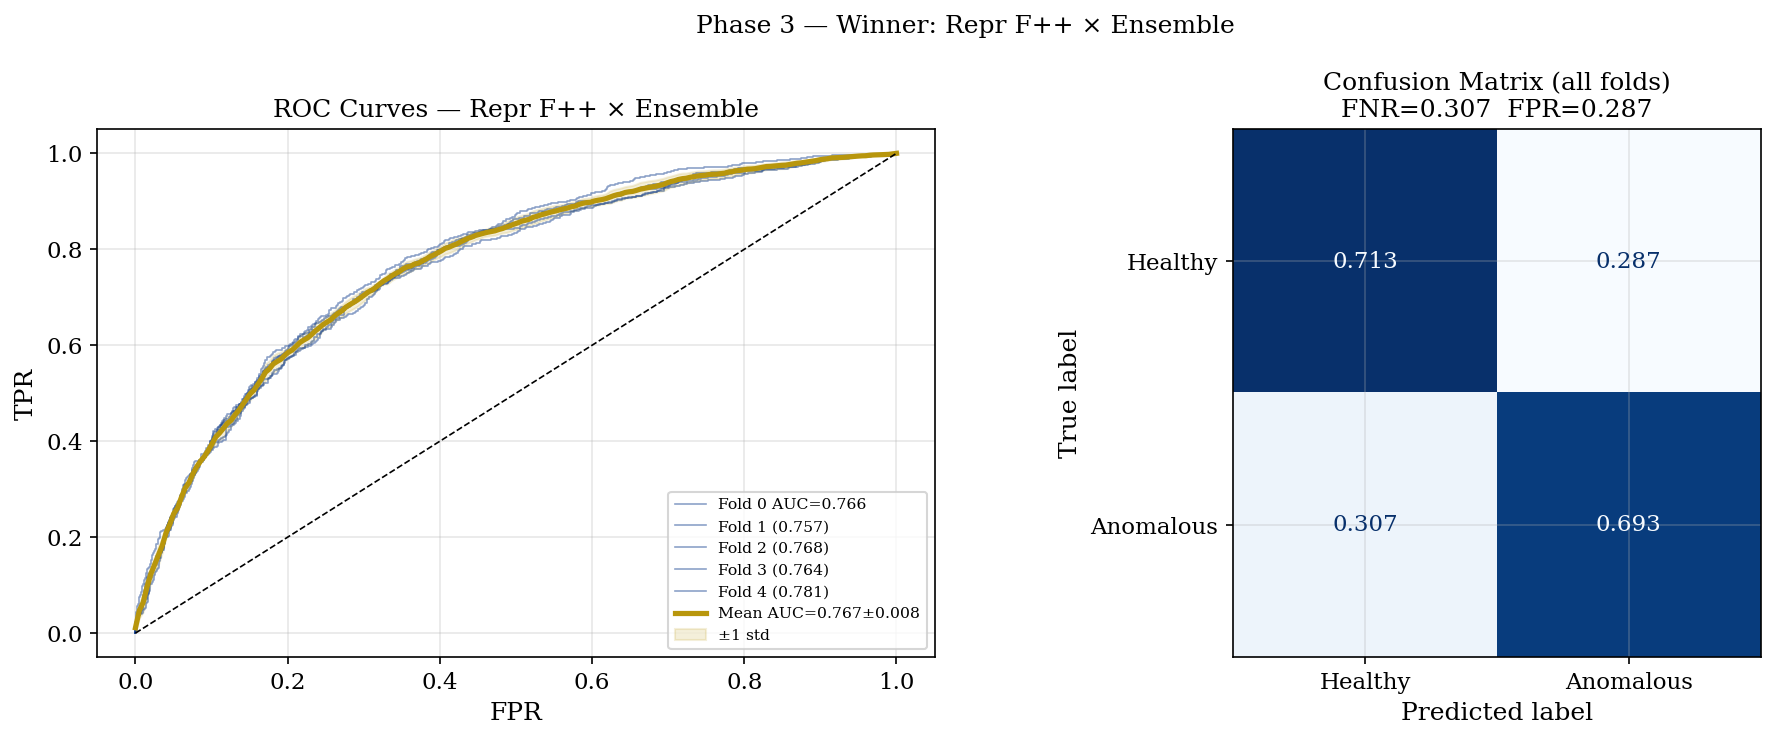

In [16]:
# ── ROC curves — 5 folds + mean ± std ────────────────────────────────────────
win_repr  = best_data['repr']
win_model = best_data['best_estimator']
X_w, y_w, folds_w = reprs[win_repr]

_, _, fold_raw = run_cv(win_model, X_w, y_w, folds_w, collect_curves=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: ROC
ax = axes[0]
tprs, aucs = [], []
mean_fpr = np.linspace(0, 1, 200)
for fold_i, fd in enumerate(fold_raw):
    fpr, tpr, _ = roc_curve(fd['y_te'], fd['y_prob'])
    auc_fold = roc_auc_score(fd['y_te'], fd['y_prob'])
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    aucs.append(auc_fold)
    ax.plot(fpr, tpr, lw=0.8, alpha=0.45, color=NPS_BLUE,
            label=f'Fold {fold_i} AUC={auc_fold:.3f}' if fold_i == 0 else f'Fold {fold_i} ({auc_fold:.3f})')

mean_tpr = np.mean(tprs, axis=0)
std_tpr  = np.std(tprs, axis=0)
ax.plot(mean_fpr, mean_tpr, color=NPS_GOLD, lw=2.5,
        label=f'Mean AUC={np.mean(aucs):.3f}±{np.std(aucs):.3f}')
ax.fill_between(mean_fpr, mean_tpr-std_tpr, mean_tpr+std_tpr,
                color=NPS_GOLD, alpha=0.15, label='±1 std')
ax.plot([0,1],[0,1],'k--',lw=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC Curves — {best_key}')
ax.legend(fontsize=7.5, loc='lower right')

# Right: Confusion Matrix (aggregate over all folds)
ax2 = axes[1]
all_y_te   = np.concatenate([fd['y_te']   for fd in fold_raw])
all_y_pred = np.concatenate([fd['y_pred'] for fd in fold_raw])
cm = confusion_matrix(all_y_te, all_y_pred, normalize='true')
disp = ConfusionMatrixDisplay(cm, display_labels=['Healthy', 'Anomalous'])
disp.plot(ax=ax2, cmap='Blues', colorbar=False, values_format='.3f')
tn, fp, fn, tp = confusion_matrix(all_y_te, all_y_pred).ravel()
ax2.set_title(f'Confusion Matrix (all folds)\nFNR={fn/(fn+tp):.3f}  FPR={fp/(fp+tn):.3f}')

plt.suptitle(f'Phase 3 — Winner: {best_key}', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'ad-phase3-roc-cm.png', bbox_inches='tight', dpi=300)
plt.show()

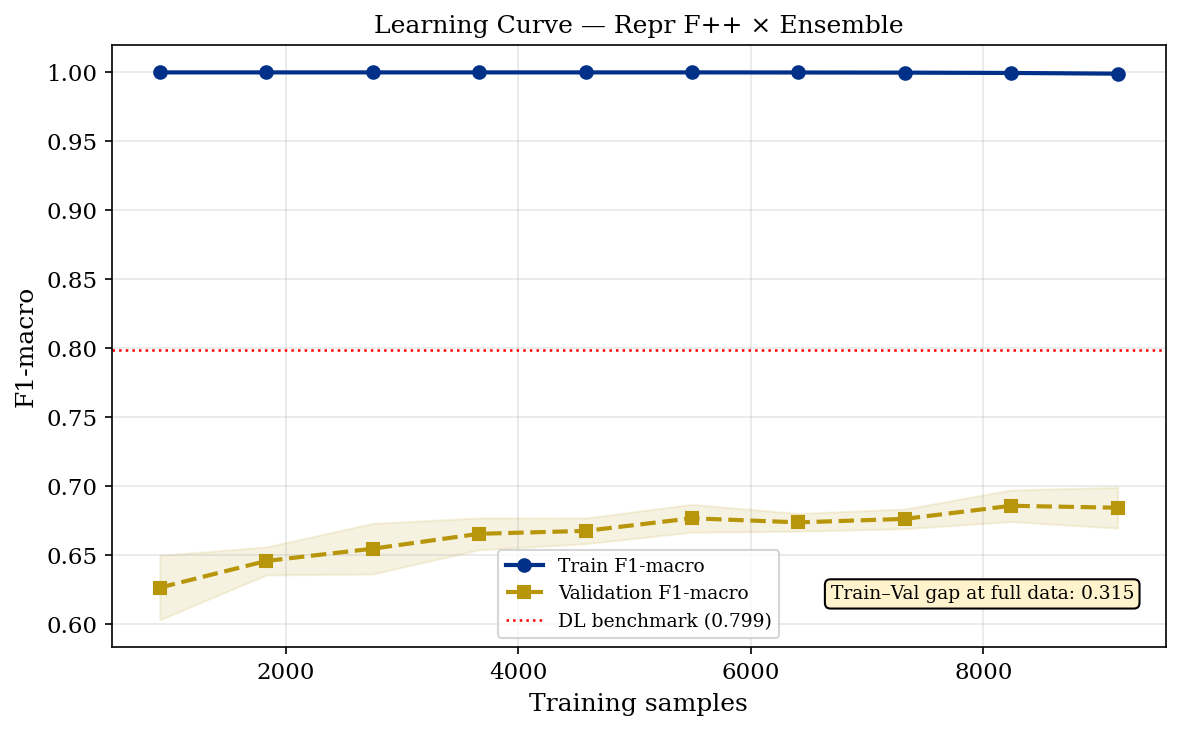

Train F1 @ full data  : 0.999 ± 0.000
Val   F1 @ full data  : 0.685 ± 0.015
Gap (bias/variance)   : 0.315  (HIGH VARIANCE)


In [17]:
# ── Learning curve — diagnose bias/variance ──────────────────────────────────
from sklearn.pipeline import Pipeline

# Build pipeline with scaler to use learning_curve properly
pipe = Pipeline([('scaler', StandardScaler()), ('clf', win_model)])

train_sizes, train_scores, val_scores = learning_curve(
    pipe, X_w, y_w,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='f1_macro',
    n_jobs=-1, random_state=RNG
)

fig, ax = plt.subplots(figsize=(8, 5))
tr_mean = train_scores.mean(axis=1)
tr_std  = train_scores.std(axis=1)
va_mean = val_scores.mean(axis=1)
va_std  = val_scores.std(axis=1)

ax.plot(train_sizes, tr_mean, 'o-', color=NPS_BLUE, lw=2, label='Train F1-macro')
ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.12, color=NPS_BLUE)
ax.plot(train_sizes, va_mean, 's--', color=NPS_GOLD, lw=2, label='Validation F1-macro')
ax.fill_between(train_sizes, va_mean-va_std, va_mean+va_std, alpha=0.12, color=NPS_GOLD)
ax.axhline(0.799, ls=':', c='red', lw=1.2, label='DL benchmark (0.799)')
ax.set_xlabel('Training samples')
ax.set_ylabel('F1-macro')
ax.set_title(f'Learning Curve — {best_key}')
ax.legend(fontsize=9)

gap = tr_mean[-1] - va_mean[-1]
ax.text(0.97, 0.08, f'Train–Val gap at full data: {gap:.3f}',
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#fff3cd'))

plt.tight_layout()
plt.savefig(FIGS / 'ad-phase3-learning-curve.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'Train F1 @ full data  : {tr_mean[-1]:.3f} ± {tr_std[-1]:.3f}')
print(f'Val   F1 @ full data  : {va_mean[-1]:.3f} ± {va_std[-1]:.3f}')
print(f'Gap (bias/variance)   : {gap:.3f}  ({"HIGH VARIANCE" if gap>0.05 else "OK"})')

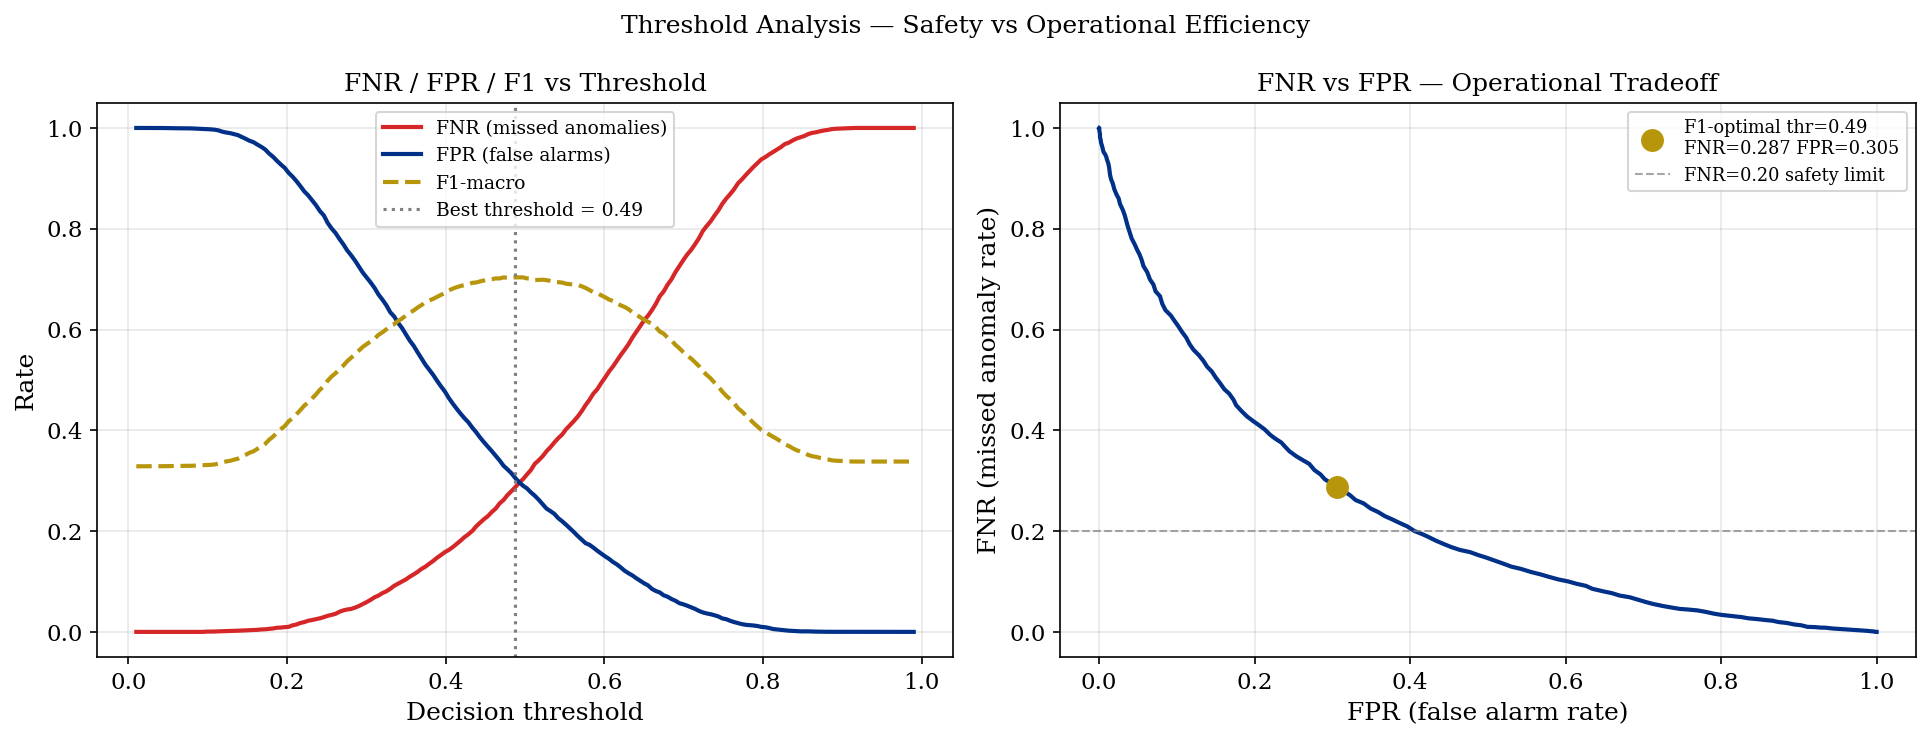

F1-optimal threshold  : 0.49  → FNR=0.287  FPR=0.305


In [18]:
# ── Threshold analysis — FNR vs FPR tradeoff ────────────────────────────────
all_y_te   = np.concatenate([fd['y_te']   for fd in fold_raw])
all_y_prob = np.concatenate([fd['y_prob'] for fd in fold_raw])

thresholds = np.linspace(0.01, 0.99, 200)
fnrs, fprs, f1s = [], [], []
for thr in thresholds:
    y_t = (all_y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_y_te, y_t, labels=[0,1]).ravel()
    fnrs.append(fn / (fn + tp) if (fn + tp) > 0 else 0)
    fprs.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    f1s.append(f1_score(all_y_te, y_t, average='macro', zero_division=0))

best_thr_idx = np.argmax(f1s)
best_thr = thresholds[best_thr_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(thresholds, fnrs, color='#d62728', lw=2, label='FNR (missed anomalies)')
ax.plot(thresholds, fprs, color=NPS_BLUE,  lw=2, label='FPR (false alarms)')
ax.plot(thresholds, f1s,  color=NPS_GOLD,  lw=2, ls='--', label='F1-macro')
ax.axvline(best_thr, ls=':', c='gray', lw=1.5,
           label=f'Best threshold = {best_thr:.2f}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Rate')
ax.set_title('FNR / FPR / F1 vs Threshold')
ax.legend(fontsize=9)

# Safety-aware threshold: find lowest threshold where FNR ≤ 0.20
safe_idx = next((i for i, v in enumerate(fnrs) if v <= 0.20), None)
ax2 = axes[1]
ax2.plot(fprs, fnrs, color=NPS_BLUE, lw=2)
ax2.scatter(fprs[best_thr_idx], fnrs[best_thr_idx], s=100, c=NPS_GOLD, zorder=5,
            label=f'F1-optimal thr={best_thr:.2f}\nFNR={fnrs[best_thr_idx]:.3f} FPR={fprs[best_thr_idx]:.3f}')
if safe_idx:
    ax2.scatter(fprs[safe_idx], fnrs[safe_idx], s=100, c='#d62728', marker='D', zorder=5,
                label=f'Safety thr (FNR≤0.20)\nthr={thresholds[safe_idx]:.2f} FPR={fprs[safe_idx]:.3f}')
ax2.axhline(0.20, ls='--', c='gray', lw=1, alpha=0.7, label='FNR=0.20 safety limit')
ax2.set_xlabel('FPR (false alarm rate)')
ax2.set_ylabel('FNR (missed anomaly rate)')
ax2.set_title('FNR vs FPR — Operational Tradeoff')
ax2.legend(fontsize=8.5)

plt.suptitle('Threshold Analysis — Safety vs Operational Efficiency', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'ad-phase3-threshold.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'F1-optimal threshold  : {best_thr:.2f}  → FNR={fnrs[best_thr_idx]:.3f}  FPR={fprs[best_thr_idx]:.3f}')
if safe_idx:
    print(f'Safety threshold (FNR≤0.20): {thresholds[safe_idx]:.2f}  → FPR={fprs[safe_idx]:.3f}')

---
## 6 · Interpretability — What did the model learn?

Interpretability serves two roles:
1. **Validation**: do the most important features match what the EDA predicted?
   (EGT and CHT should dominate; AltMSL and VSpd should not)
2. **Diagnosis**: if the model mainly uses `AltMSL_mean`, it is learning
   the flight profile, not the fault — a sign of data leakage or selection bias.

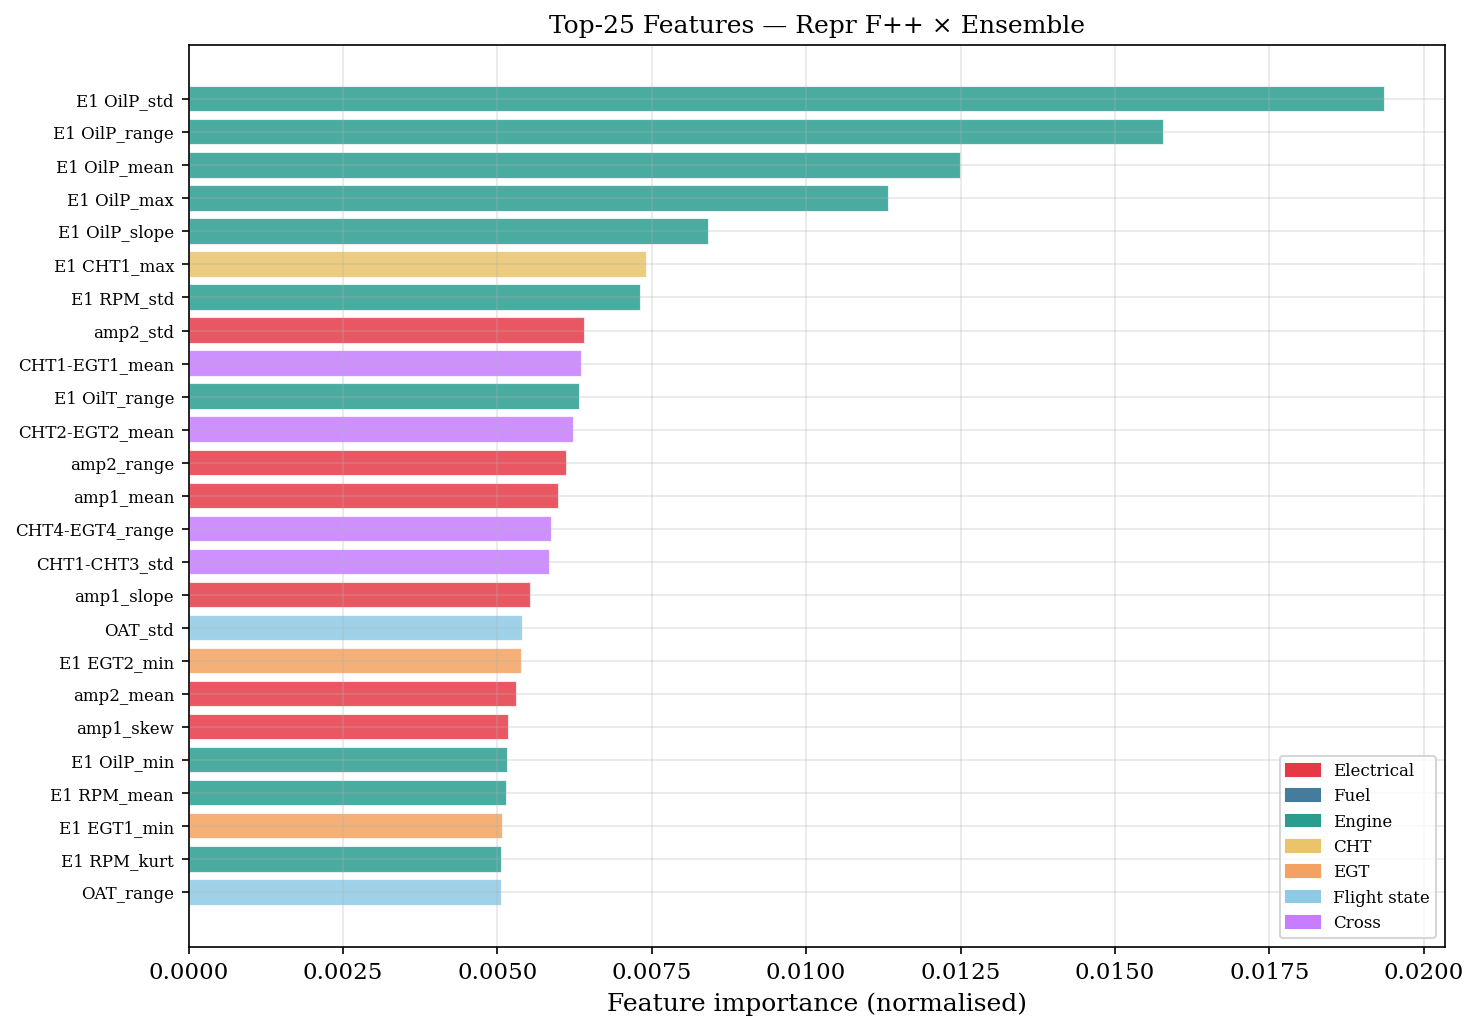

In [19]:
# ── Feature importance (XGB gain + RF impurity) ──────────────────────────────
# Fit on full scaled dataset for importance extraction
X_w, y_w, folds_w = reprs[win_repr]
sc_full = StandardScaler()
X_sc = sc_full.fit_transform(X_w)
sw = compute_sample_weight('balanced', y_w)

# Use the best estimator directly (already fitted during tuning)
base = best_data['best_estimator']

# Get importances based on model type
def get_importances(model, feat_names):
    if isinstance(model, XGBClassifier):
        return model.feature_importances_
    elif isinstance(model, RandomForestClassifier):
        return model.feature_importances_
    elif isinstance(model, VotingClassifier):
        # average RF and XGB importances from sub-estimators
        parts = []
        for name, est in model.named_estimators_.items():
            if hasattr(est, 'feature_importances_'):
                parts.append(est.feature_importances_)
        return np.mean(parts, axis=0) if parts else None
    elif isinstance(model, LogisticRegression):
        return np.abs(model.coef_[0])
    else:
        return None

# Refit on full data for stable importances
if isinstance(base, XGBClassifier):
    base.fit(X_sc, y_w, sample_weight=sw)
else:
    base.fit(X_sc, y_w)

# Get feature names for the current representation
n_feat = X_w.shape[1]
if n_feat == 184:
    feat_names = FEAT_B
elif n_feat == 224:
    from itertools import combinations
    CHT = ['E1 CHT1','E1 CHT2','E1 CHT3','E1 CHT4']
    EGT = ['E1 EGT1','E1 EGT2','E1 EGT3','E1 EGT4']
    cross_names = ([f'CHT{a+1}-CHT{b+1}_{st}' for a,b in combinations(range(4),2) for st in ['mean','std','range','slope']] +
                   [f'CHT{i+1}-EGT{i+1}_{st}' for i in range(4) for st in ['mean','std','range','slope']])
    feat_names = FEAT_B + cross_names
else:
    feat_names = [f'f{i}' for i in range(n_feat)]

importances = get_importances(base, feat_names)

if importances is not None and len(importances) == len(feat_names):
    TOP_N = 25
    top_idx = np.argsort(importances)[::-1][:TOP_N]
    top_names = [feat_names[i] for i in top_idx]
    top_vals  = importances[top_idx]

    # Colour by sensor group
    group_color = {
        'Electrical':'#e63946','Fuel':'#457b9d','Engine':'#2a9d8f',
        'CHT':'#e9c46a','EGT':'#f4a261','Flight state':'#8ecae6','Cross':'#c77dff'
    }
    sensor_to_group = {s: g for g, ss in SENSOR_GROUPS.items() for s in ss}

    def feat_color(name):
        for sensor, grp in sensor_to_group.items():
            if sensor in name: return group_color[grp]
        if 'CHT' in name and 'EGT' in name: return group_color['Cross']
        if name.startswith('CHT'):           return group_color['Cross']
        return '#adb5bd'

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = [feat_color(n) for n in top_names]
    ax.barh(range(TOP_N), top_vals[::-1], color=colors[::-1], alpha=0.85, edgecolor='white')
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_names[::-1], fontsize=8)
    ax.set_xlabel('Feature importance (normalised)')
    ax.set_title(f'Top-{TOP_N} Features — {best_key}')
    patches = [mpatches.Patch(color=c, label=g) for g, c in group_color.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGS / 'ad-feature-importance.png', bbox_inches='tight', dpi=300)
    plt.show()
else:
    print('Feature importances not available for this model type.')

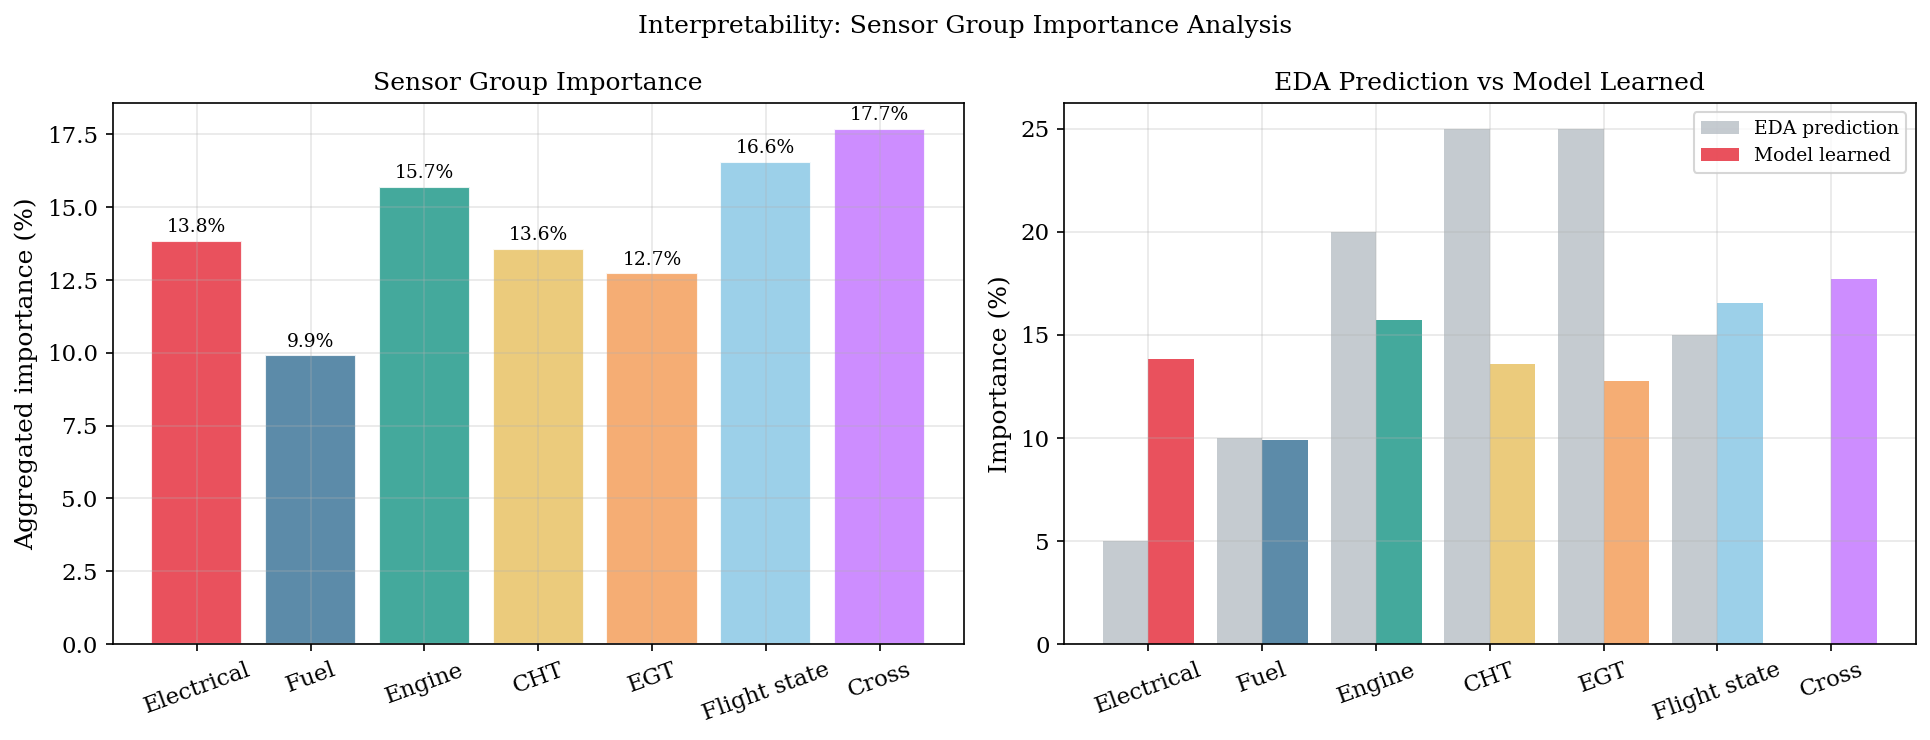

Sensor group breakdown:
  Cross           17.7%  ████████
  Flight state    16.6%  ████████
  Engine          15.7%  ███████
  Electrical      13.8%  ██████
  CHT             13.6%  ██████
  EGT             12.7%  ██████
  Fuel             9.9%  ████


In [20]:
# ── Sensor-group importance aggregation ──────────────────────────────────────
if importances is not None and len(importances) == len(feat_names):
    group_imp = {g: 0.0 for g in SENSOR_GROUPS}
    group_imp['Cross'] = 0.0

    for name, imp in zip(feat_names, importances):
        assigned = False
        for sensor, grp in sensor_to_group.items():
            if sensor in name:
                group_imp[grp] += imp
                assigned = True
                break
        if not assigned:
            group_imp['Cross'] += imp

    # Normalise
    total = sum(group_imp.values())
    group_pct = {g: v/total*100 for g, v in group_imp.items()}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    groups = list(group_pct.keys())
    vals   = list(group_pct.values())
    clrs   = [group_color.get(g, '#adb5bd') for g in groups]
    bars = ax.bar(groups, vals, color=clrs, alpha=0.88, edgecolor='white')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)
    ax.set_ylabel('Aggregated importance (%)')
    ax.set_title('Sensor Group Importance')
    ax.tick_params(axis='x', rotation=20)

    # EDA prediction vs model learned
    ax2 = axes[1]
    eda_prediction = {
        'Electrical': 5, 'Fuel': 10, 'Engine': 20,
        'CHT': 25, 'EGT': 25, 'Flight state': 15, 'Cross': 0
    }
    x_g = np.arange(len(groups))
    ax2.bar(x_g - 0.2, [eda_prediction.get(g, 0) for g in groups], 0.4,
            label='EDA prediction', color='#adb5bd', alpha=0.7)
    ax2.bar(x_g + 0.2, vals, 0.4,
            label='Model learned', color=clrs, alpha=0.88)
    ax2.set_xticks(x_g)
    ax2.set_xticklabels(groups, rotation=20)
    ax2.set_ylabel('Importance (%)')
    ax2.set_title('EDA Prediction vs Model Learned')
    ax2.legend(fontsize=9)

    plt.suptitle('Interpretability: Sensor Group Importance Analysis', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGS / 'ad-sensor-group-importance.png', bbox_inches='tight', dpi=300)
    plt.show()

    print('Sensor group breakdown:')
    for g, pct in sorted(group_pct.items(), key=lambda x: -x[1]):
        bar = '█' * int(pct/2)
        print(f'  {g:14s} {pct:5.1f}%  {bar}')

---
## 7 · Final Table and Decision

In [21]:
# ── Final comparison table ────────────────────────────────────────────────────
rows = []

# All Phase 1 combos (sorted by F1)
for r, m, f1, fnr, auc in pairs:
    rows.append({
        'Model'  : m,
        'Repr'   : r,
        'F1'     : round(f1, 3),
        'AUC'    : round(results_p1[r][m]['means']['auc'], 3),
        'FNR'    : round(fnr, 3),
        'FPR'    : round(results_p1[r][m]['means']['fpr'], 3),
        'Tuned'  : '',
        'Note'   : ''
    })

# Tuned results
for key, data in tuned_results.items():
    rows.append({
        'Model'  : data['model'],
        'Repr'   : data['repr'],
        'F1'     : round(data['means']['f1'], 3),
        'AUC'    : round(data['means']['auc'], 3),
        'FNR'    : round(data['means']['fnr'], 3),
        'FPR'    : round(data['means']['fpr'], 3),
        'Tuned'  : '✓',
        'Note'   : 'tuned'
    })

# DL benchmarks from paper
dl_benchmarks = [
    {'Model':'ConvTokMHSA', 'Repr':'Repr A', 'F1':0.799, 'AUC':None, 'FNR':0.163, 'FPR':None, 'Tuned':'—', 'Note':'DL paper'},
    {'Model':'InceptionTime','Repr':'Repr A', 'F1':0.784, 'AUC':None, 'FNR':0.196, 'FPR':None, 'Tuned':'—', 'Note':'DL paper'},
    {'Model':'MMK Net',      'Repr':'Repr A', 'F1':0.721, 'AUC':None, 'FNR':0.298, 'FPR':None, 'Tuned':'—', 'Note':'DL paper'},
]
rows.extend(dl_benchmarks)

df_final = pd.DataFrame(rows)
df_final = df_final.sort_values('F1', ascending=False).reset_index(drop=True)

print('\n=== FINAL AD RESULTS TABLE ===')
print(df_final.to_string(index=False))

# Save
df_final.to_csv(RESULTS / 'ad_results.csv', index=False)
print(f'\nSaved to {RESULTS}/ad_results.csv')


=== FINAL AD RESULTS TABLE ===
        Model        Repr    F1   AUC   FNR   FPR Tuned     Note
  ConvTokMHSA      Repr A 0.799   NaN 0.163   NaN     — DL paper
InceptionTime      Repr A 0.784   NaN 0.196   NaN     — DL paper
      MMK Net      Repr A 0.721   NaN 0.298   NaN     — DL paper
     Ensemble    Repr F++ 0.703 0.767 0.307 0.287     ✓    tuned
     Ensemble    Repr F++ 0.697 0.762 0.314 0.292               
     Ensemble  Repr Bseg3 0.693 0.758 0.322 0.291               
     Ensemble      Repr B 0.691 0.754 0.322 0.296     ✓    tuned
     Ensemble      Repr B 0.689 0.757 0.322 0.300               
     Ensemble  Repr Bseg3 0.687 0.751 0.329 0.296     ✓    tuned
      XGBoost    Repr F++ 0.687 0.756 0.317 0.308               
     Ensemble  Repr Bseg5 0.687 0.750 0.332 0.293               
     Ensemble Repr Bseg10 0.680 0.746 0.334 0.306               
           LR      Repr B 0.679 0.730 0.308 0.333               
           LR    Repr F++ 0.678 0.732 0.310 0.333         

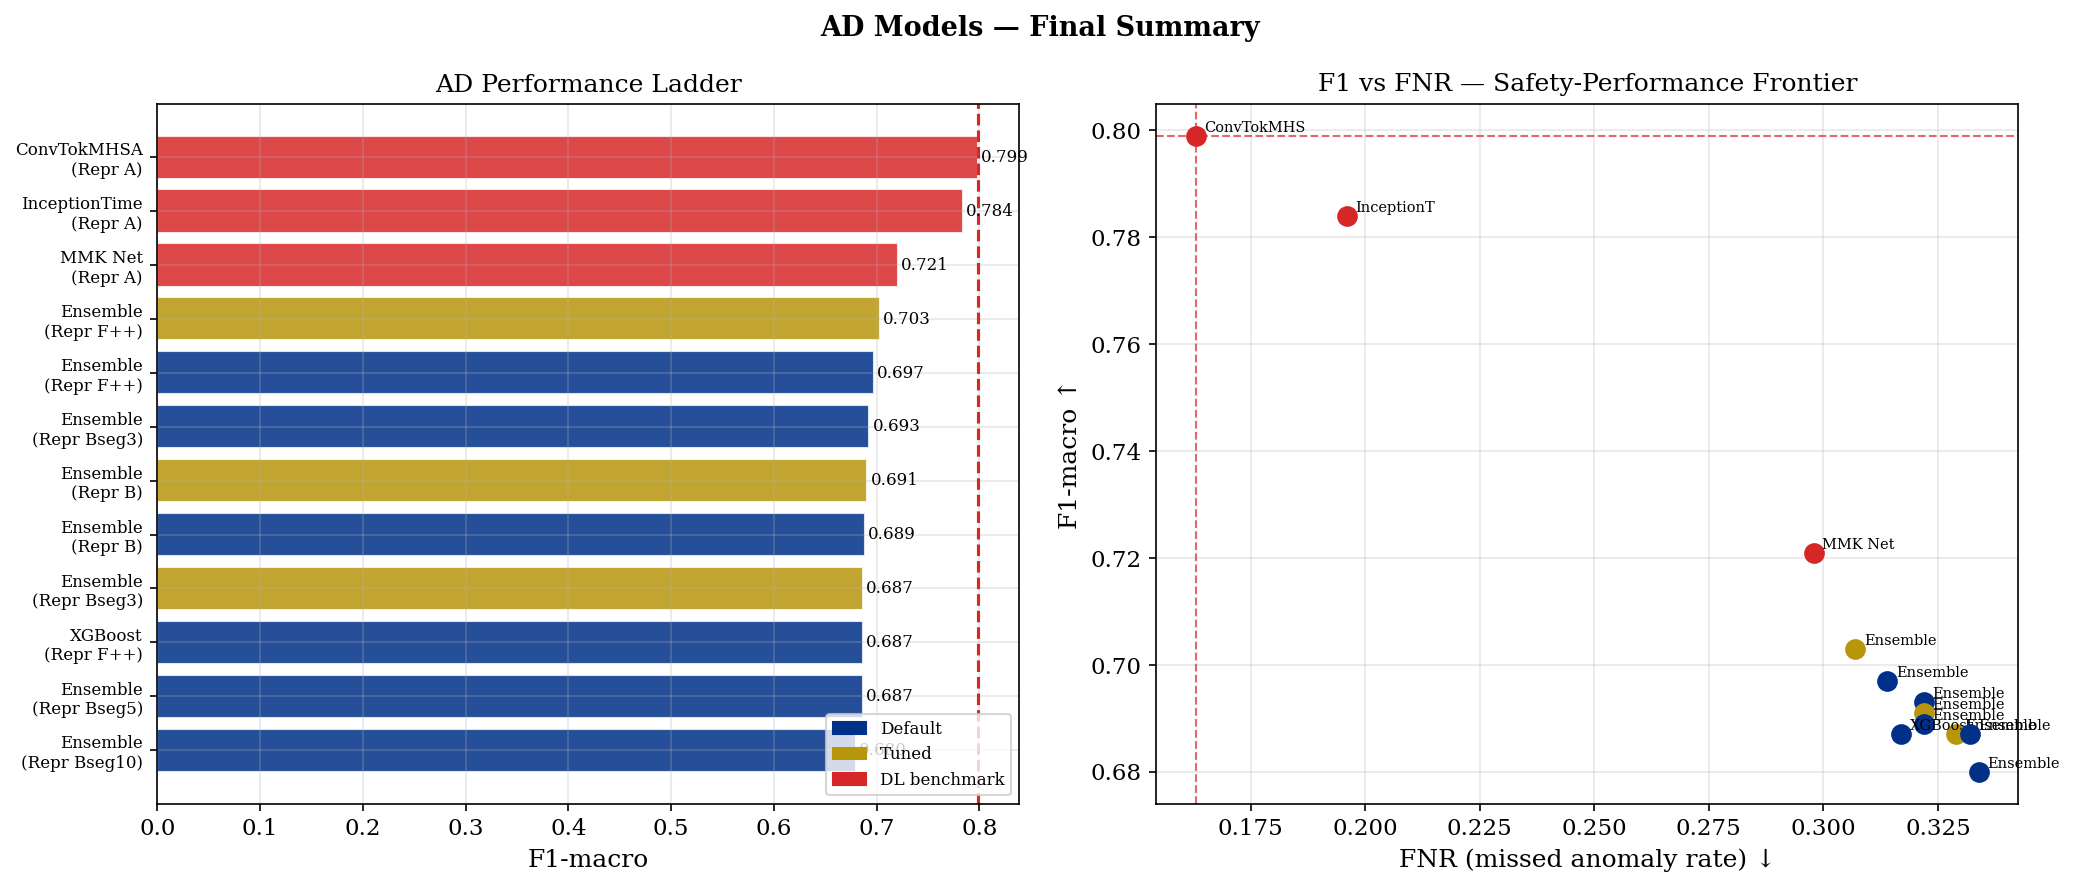


DECISION: BEST CLASSICAL AD MODEL
  Model       : Ensemble
  Repr        : Repr F++
  F1-macro    : 0.703
  AUC-ROC     : 0.767
  FNR         : 0.307
  Gap vs DL   : 0.096 F1 points
→ This model passes to the E2E cascade pipeline (05_E2E_Models.ipynb)


In [22]:
# ── Final summary figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: F1 ladder
ax = axes[0]
show_df = df_final[['Model','Repr','F1','FNR','Note']].head(12).copy()
show_df['label'] = show_df['Model'] + '\n(' + show_df['Repr'] + ')'
colors_bar = ['#d62728' if r=='DL paper' else
              NPS_GOLD   if r=='tuned'    else
              NPS_BLUE   for r in show_df['Note']]
bars = ax.barh(range(len(show_df)), show_df['F1'], color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(show_df)))
ax.set_yticklabels(show_df['label'], fontsize=8)
ax.invert_yaxis()
ax.axvline(0.799, ls='--', c='#d62728', lw=1.5, label='DL ConvTokMHSA')
ax.set_xlabel('F1-macro')
ax.set_title('AD Performance Ladder')
for b, v in zip(bars, show_df['F1']):
    ax.text(v+0.003, b.get_y()+b.get_height()/2, f'{v:.3f}', va='center', fontsize=8)
patches_leg = [
    mpatches.Patch(color=NPS_BLUE,  label='Default'),
    mpatches.Patch(color=NPS_GOLD,  label='Tuned'),
    mpatches.Patch(color='#d62728', label='DL benchmark'),
]
ax.legend(handles=patches_leg, fontsize=8, loc='lower right')

# Right: F1 vs FNR scatter
ax2 = axes[1]
for _, row in show_df.iterrows():
    if pd.isna(row['FNR']): continue
    c = '#d62728' if row['Note']=='DL paper' else \
        NPS_GOLD   if row['Note']=='tuned'    else NPS_BLUE
    ax2.scatter(row['FNR'], row['F1'], c=c, s=80, zorder=3)
    ax2.annotate(row['Model'][:10], (row['FNR'], row['F1']),
                 fontsize=7, xytext=(4, 2), textcoords='offset points')
ax2.axhline(0.799, ls='--', c='#d62728', lw=1, alpha=0.7)
ax2.axvline(0.163, ls='--', c='#d62728', lw=1, alpha=0.7)
ax2.set_xlabel('FNR (missed anomaly rate) ↓')
ax2.set_ylabel('F1-macro ↑')
ax2.set_title('F1 vs FNR — Safety-Performance Frontier')

plt.suptitle('AD Models — Final Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'ad-final-summary.png', bbox_inches='tight', dpi=300)
plt.show()

# Decision
best_classical = df_final[df_final['Note'] != 'DL paper'].iloc[0]
print('\n' + '='*65)
print('DECISION: BEST CLASSICAL AD MODEL')
print('='*65)
print(f'  Model       : {best_classical["Model"]}')
print(f'  Repr        : {best_classical["Repr"]}')
print(f'  F1-macro    : {best_classical["F1"]:.3f}')
print(f'  AUC-ROC     : {best_classical["AUC"]}')
print(f'  FNR         : {best_classical["FNR"]:.3f}')
print(f'  Gap vs DL   : {0.799 - float(best_classical["F1"]):.3f} F1 points')
print('='*65)
print('→ This model passes to the E2E cascade pipeline (05_E2E_Models.ipynb)')